## Data Preparation



In [1]:
import numpy as np
import pandas as pd

In [2]:
# Define parameters
num_cities = 10
num_months = 12

# Generate synthetic temperature data
temperature_data = np.random.uniform(low=-5, high=35, size=(num_cities, num_months))

# Display the generated data
print("Generated Temperature Data (first 3 rows):\n", temperature_data[:3])

Generated Temperature Data (first 3 rows):
 [[-3.64789555  2.87021958  0.8681384  13.77306371 19.95095559 15.4949745
  16.66467769 19.04625246 25.69819044 12.13309399  1.41925451 30.68039184]
 [16.03245417  6.79059828 -1.11209299  0.71491741  9.57408459 15.71420911
  22.91504978 29.78281919 30.38404745 10.71697961 32.51927718 -3.74685939]
 [ 4.84344765 -1.53226215  3.49513071  8.36364861 18.59317968  5.51495552
   9.60247425  5.02487531 25.86941476 10.63894388 18.8074514  32.04999421]]


### Create Pandas DataFrame



In [3]:
# Create city names and month names
city_names = [f'City_{i+1}' for i in range(num_cities)]
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Create DataFrame
df_temperatures = pd.DataFrame(temperature_data, index=city_names, columns=month_names)

# Display the first few rows of the DataFrame
display(df_temperatures.head())

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
City_1,-3.647896,2.870220,0.868138,13.773064,19.950956,15.494974,16.664678,19.046252,25.698190,12.133094,1.419255,30.680392
City_2,16.032454,6.790598,-1.112093,0.714917,9.574085,15.714209,22.915050,29.782819,30.384047,10.716980,32.519277,-3.746859
City_3,4.843448,-1.532262,3.495131,8.363649,18.593180,5.514956,9.602474,5.024875,25.869415,10.638944,18.807451,32.049994
City_4,-3.812911,9.744616,27.680043,11.783949,-0.621832,-1.033454,30.471806,26.423714,3.244593,24.327395,16.920248,8.470729
City_5,18.555631,12.440408,21.230453,32.444933,29.529705,6.891530,32.258027,19.432575,20.753066,30.336843,25.996947,7.475083


## 2. Data Analysis


In [4]:
# Calculate the annual average temperature for each city
df_temperatures['Annual_Average_Temp'] = df_temperatures.mean(axis=1)

# Display the DataFrame with the new column
display(df_temperatures[['Annual_Average_Temp']].head())

,Annual_Average_Temp
City_1,12.912610
City_2,14.190457
City_3,11.772604
City_4,12.799908
City_5,21.445433


### Identify Cities with Highest and Lowest Annual Average Temperatures



In [5]:
# Find the city with the highest annual average temperature
city_highest_temp = df_temperatures['Annual_Average_Temp'].idxmax()
highest_avg_temp = df_temperatures['Annual_Average_Temp'].max()

# Find the city with the lowest annual average temperature
city_lowest_temp = df_temperatures['Annual_Average_Temp'].idxmin()
lowest_avg_temp = df_temperatures['Annual_Average_Temp'].min()

print(f"City with the highest annual average temperature: {city_highest_temp} ({highest_avg_temp:.2f}°C)")
print(f"City with the lowest annual average temperature: {city_lowest_temp} ({lowest_avg_temp:.2f}°C)")

City with the highest annual average temperature: City_5 (21.45°C)
City with the lowest annual average temperature: City_7 (9.36°C)


## 3. Data Visualization

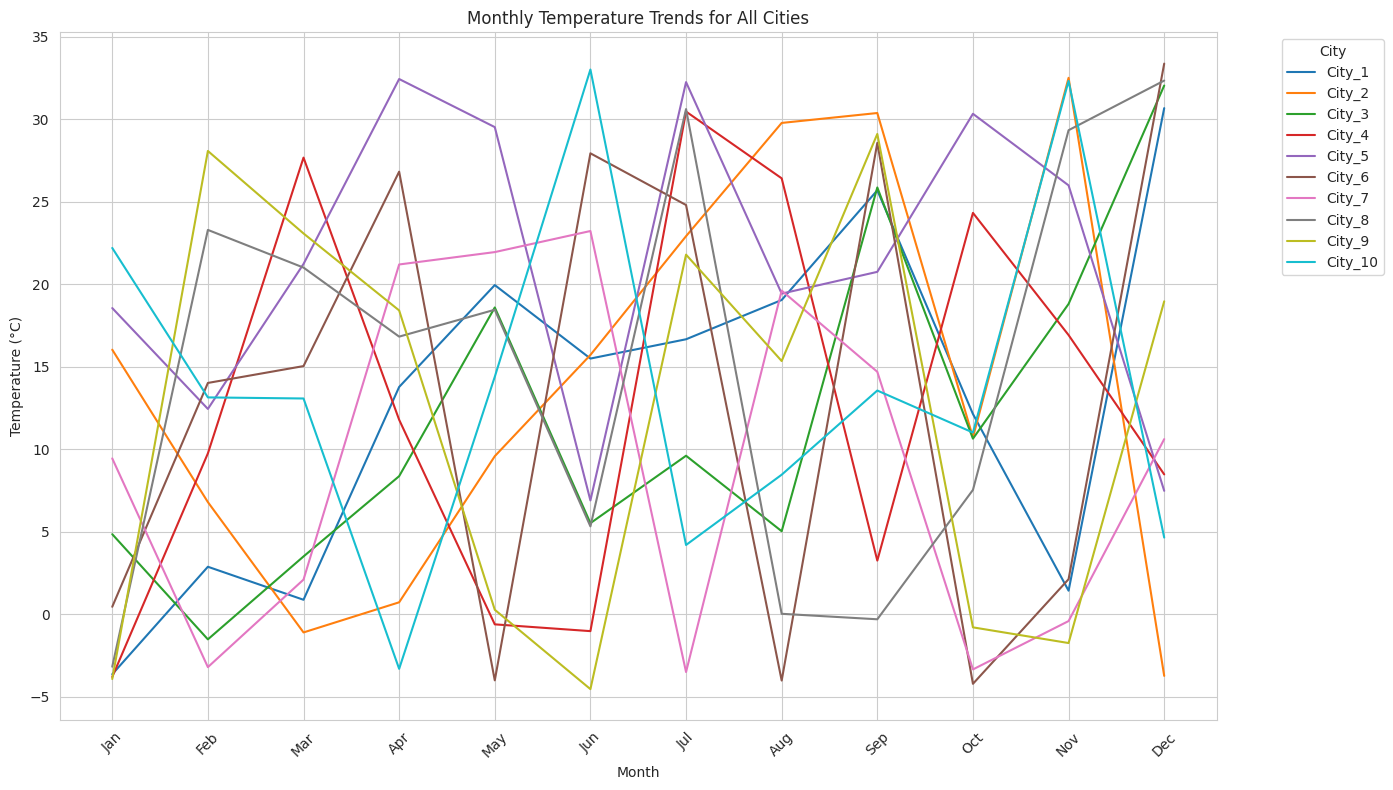

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots
sns.set_style("whitegrid")

# Plotting monthly temperature trends for all cities
plt.figure(figsize=(14, 8))
sns.lineplot(data=df_temperatures[month_names].T, dashes=False)
plt.title('Monthly Temperature Trends for All Cities')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Visualization of Annual Average Temperatures



/tmp/ipykernel_3650/2849421885.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_temperatures.index, y='Annual_Average_Temp', data=df_temperatures, palette='viridis')


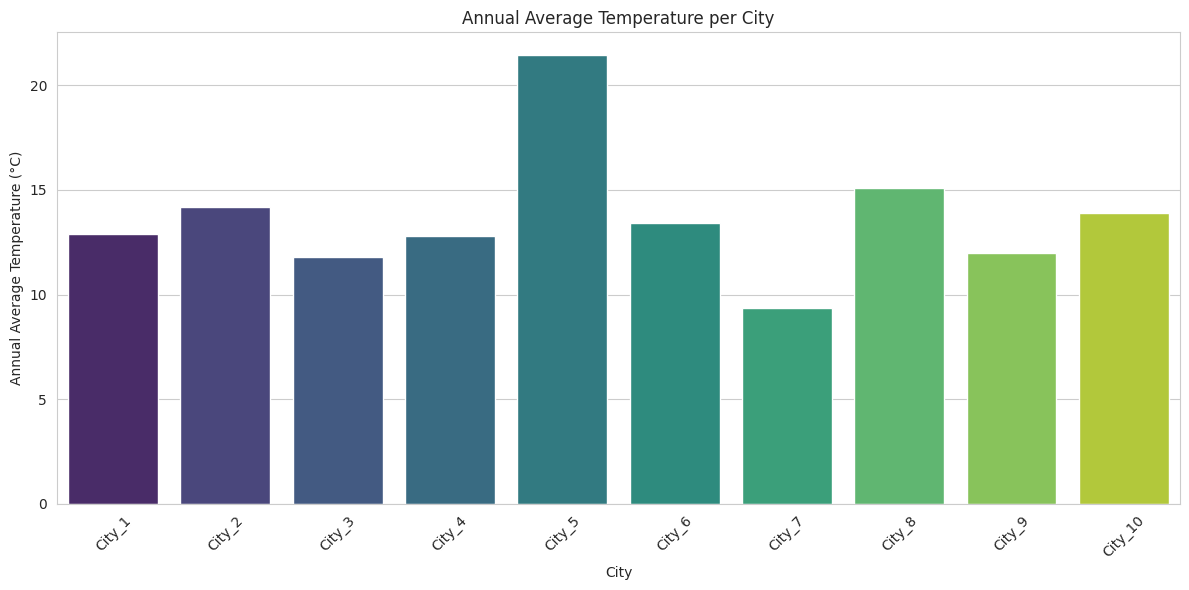

In [7]:
plt.figure(figsize=(12, 6))
sns.barplot(x=df_temperatures.index, y='Annual_Average_Temp', data=df_temperatures, palette='viridis')
plt.title('Annual Average Temperature per City')
plt.xlabel('City')
plt.ylabel('Annual Average Temperature (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()